# RLHF (DPO + PPO-RLHF)
This notebook trains DPO and PPO-RLHF from preference datasets produced in the previous step.

Notes:
- Change `ENV_KEY` to switch environments (e.g., `cartpole`, `pendulum`).
- Dataset sizes K are inferred from pickle filenames (e.g., `_K50.pkl`).

In [1]:
from __future__ import annotations

import re
import pickle
import copy
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.ppo.policies import MlpPolicy

In [52]:
ENV_KEY = "cartpole"  # change to: cartpole | pendulum
ENV_ID_MAP = {"cartpole": "CartPole-v1", "pendulum": "Pendulum-v1"}
ENV_ID = ENV_ID_MAP.get(ENV_KEY, ENV_KEY)
temp_env = gym.make(ENV_ID)
ENV_CONTINUOUS = isinstance(temp_env.action_space, gym.spaces.Box)
ENV_OBS_DIM = temp_env.observation_space.shape[0]
ENV_ACTION_DIM = temp_env.action_space.shape[0] if ENV_CONTINUOUS else temp_env.action_space.n

DATASET_ROOT = Path("outputs/datasets")
OUTPUT_DIR = Path("outputs/part3")
CHECKPOINT_DIR = Path("outputs/checkpoints")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# DPO config
DPO_BETA = 0.1
DPO_EPOCHS = 5
DPO_BATCH_SIZE = 16
DPO_LR = 3e-4

# Reward model config
RM_EPOCHS = 500
RM_BATCH_SIZE = 16
RM_LR = 1e-3

# PPO-RLHF config
PPO_TIMESTEPS = 100_000
CHECKPOINT_STEPS = 1024
PPO_LR = 3e-4
PPO_N_STEPS = 1024
PPO_BATCH_SIZE = 64
PPO_GAMMA = 0.99

# Evaluation
EVAL_EPISODES = 20

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: cpu


## Dataset discovery + normalization

In [4]:
K_REGEX = re.compile(r"_K(\d+)", re.IGNORECASE)
SEED_REGEX = re.compile(r"seed(\d+)", re.IGNORECASE)


@dataclass
class PreferenceDataset:
    env_key: str
    k: int
    seed: int
    path: Path
    s_pref_list: List[np.ndarray]
    a_pref_list: List[np.ndarray]
    s_rej_list: List[np.ndarray]
    a_rej_list: List[np.ndarray]


def load_preference_datasets(env_key: str) -> List[PreferenceDataset]:
    pattern = f"{env_key.lower()}_seed*_K*.pkl"
    paths = sorted(DATASET_ROOT.glob(pattern))
    datasets: List[PreferenceDataset] = []
    for path in paths:
        m_k = K_REGEX.search(path.name)
        if not m_k:
            continue
        m_seed = SEED_REGEX.search(path.name)
        if not m_seed:
            raise ValueError(f"Missing seed in dataset filename: {path.name}")
        k = int(m_k.group(1))
        seed = int(m_seed.group(1))
        with open(path, "rb") as f:
            raw_pairs = pickle.load(f)
        s_pref_list: List[np.ndarray] = []
        a_pref_list: List[np.ndarray] = []
        s_rej_list: List[np.ndarray] = []
        a_rej_list: List[np.ndarray] = []
        for pair in raw_pairs:
            tau1 = pair["tau_1"]
            tau2 = pair["tau_2"]
            states1 = np.asarray([step[0] for step in tau1])
            actions1 = np.asarray([step[1] for step in tau1])
            states2 = np.asarray([step[0] for step in tau2])
            actions2 = np.asarray([step[1] for step in tau2])
            label = int(pair["label"])
            if label == 0:
                s_pref, a_pref = states1, actions1
                s_rej, a_rej = states2, actions2
            else:
                s_pref, a_pref = states2, actions2
                s_rej, a_rej = states1, actions1
            s_pref_list.append(s_pref)
            a_pref_list.append(a_pref)
            s_rej_list.append(s_rej)
            a_rej_list.append(a_rej)
        datasets.append(
            PreferenceDataset(
                env_key=env_key,
                k=k,
                seed=seed,
                path=path,
                s_pref_list=s_pref_list,
                a_pref_list=a_pref_list,
                s_rej_list=s_rej_list,
                a_rej_list=a_rej_list,
            )
        )
    return datasets


dataset_list = load_preference_datasets(ENV_KEY)
print(f"Loaded {len(dataset_list)} datasets for env {ENV_KEY}")

Loaded 4 datasets for env cartpole


## Loading policies

In [5]:
POLICY_SEED = 0

p1_path = CHECKPOINT_DIR / f"pi1_{ENV_KEY}_seed{POLICY_SEED}.zip"
p2_path = CHECKPOINT_DIR / f"pi2_{ENV_KEY}_seed{POLICY_SEED}.zip"
if not p1_path.exists():
    raise FileNotFoundError(f"Missing policy checkpoint: {p1_path}")
if not p2_path.exists():
    raise FileNotFoundError(f"Missing policy checkpoint: {p2_path}")

p1_policy = PPO.load(p1_path, device=DEVICE).policy
p2_policy = PPO.load(p2_path, device=DEVICE).policy
print(f"Loaded policies for {ENV_KEY} from {p1_path} and {p2_path}")

Loaded policies for cartpole from outputs\checkpoints\pi1_cartpole_seed0.zip and outputs\checkpoints\pi2_cartpole_seed0.zip


## DPO (offline policy optimization from preferences)

In [53]:
def trajectory_logprob(policy: MlpPolicy, states: np.ndarray, actions: np.ndarray) -> torch.Tensor:
    states_t = torch.tensor(states, dtype=torch.float32, device=DEVICE)

    distribution = policy.get_distribution(states_t)

    if isinstance(temp_env.action_space, gym.spaces.Discrete):
        actions_t = torch.tensor(actions, dtype=torch.long, device=DEVICE)
    else:
        actions_t = torch.tensor(actions, dtype=torch.float32, device=DEVICE)

    logp = distribution.log_prob(actions_t)

    return logp.sum()


def dpo_loss(
    policy: MlpPolicy,
    ref_policy: MlpPolicy,
    s_pref: np.ndarray,
    a_pref: np.ndarray,
    s_rej: np.ndarray,
    a_rej: np.ndarray,
    beta: float,
) -> torch.Tensor:
    logp_pref = trajectory_logprob(policy, s_pref, a_pref)
    logp_rej = trajectory_logprob(policy, s_rej, a_rej)
    logp_ref_pref = trajectory_logprob(ref_policy, s_pref, a_pref)
    logp_ref_rej = trajectory_logprob(ref_policy, s_rej, a_rej)
    adv = (logp_pref - logp_rej) - (logp_ref_pref - logp_ref_rej)
    logits = beta * adv
    labels = torch.ones_like(logits)
    return F.binary_cross_entropy_with_logits(logits, labels)


def make_env(env_id: str, seed: int) -> gym.Env:
    env = gym.make(env_id)
    env.reset(seed=seed)
    env = Monitor(env)
    return env


def eval_policy_true_reward(
    model: MlpPolicy,
    env_id: str,
    episodes: int,
    eval_seed: int,
) -> Tuple[float, float]:
    rng = np.random.default_rng(eval_seed)
    env = DummyVecEnv([lambda: make_env(env_id, seed=int(rng.integers(0, 1000000))) for _ in range(episodes)])
    mean, std = evaluate_policy(model, env, n_eval_episodes=episodes, deterministic=True)
    env.close()
    return float(mean), float(std)


def train_dpo(
    s_pref_list: List[np.ndarray],
    a_pref_list: List[np.ndarray],
    s_rej_list: List[np.ndarray],
    a_rej_list: List[np.ndarray],
    eval_seed: int,
    epochs: int = DPO_EPOCHS,
    batch_size: int = DPO_BATCH_SIZE,
    lr: float = DPO_LR,
    beta: float = DPO_BETA,
) -> Tuple[MlpPolicy, Dict[str, List[float]]]:
    policy = copy.deepcopy(p2_policy).to(DEVICE)
    ref_policy = copy.deepcopy(p2_policy).to(DEVICE)
    ref_policy.eval()
    # Explicitly freeze the reference policy
    for param in ref_policy.parameters():
        param.requires_grad = False
    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)
    n = len(s_pref_list)
    history: Dict[str, List[float]] = {
        "steps": [],
        "mean_reward": [],
        "std_reward": [],
    }
    processed_steps = 0
    next_checkpoint = CHECKPOINT_STEPS

    def record_checkpoint(step_count: int) -> None:
        was_training = policy.training
        policy.eval()
        mean_reward, std_reward = eval_policy_true_reward(
            policy,
            ENV_ID,
            EVAL_EPISODES,
            eval_seed=eval_seed,
        )
        history["steps"].append(step_count)
        history["mean_reward"].append(mean_reward)
        history["std_reward"].append(std_reward)
        if was_training:
            policy.train()

    for _ in range(epochs):
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            batch_idx = idx[start:start + batch_size]
            losses = []
            batch_steps = 0
            for i in batch_idx:
                loss = dpo_loss(
                    policy,
                    ref_policy,
                    s_pref_list[i],
                    a_pref_list[i],
                    s_rej_list[i],
                    a_rej_list[i],
                    beta,
                )
                losses.append(loss)
                batch_steps += len(s_pref_list[i]) + len(s_rej_list[i])
            if not losses:
                continue
            batch_loss = torch.stack(losses).mean()
            optimizer.zero_grad()
            batch_loss.backward()
            optimizer.step()
            processed_steps += batch_steps
            while processed_steps >= next_checkpoint:
                record_checkpoint(processed_steps)
                next_checkpoint += CHECKPOINT_STEPS
    if not history["steps"] or history["steps"][-1] != processed_steps:
        record_checkpoint(processed_steps)
    return policy, history

## PPO-RLHF (reward model + PPO)

In [54]:
class RewardModel(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int, continuous: bool):
        super().__init__()
        self.continuous = continuous
        hidden = 64
        in_dim = obs_dim + action_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )
        self.action_dim = action_dim

    def forward(self, obs: torch.Tensor, act: torch.Tensor) -> torch.Tensor:
        if self.continuous:
            act_feat = act
        else:
            act_feat = F.one_hot(act, num_classes=self.action_dim).float()
        x = torch.cat([obs, act_feat], dim=-1)
        return self.net(x).squeeze(-1)

    def trajectory_return(self, states: torch.Tensor, actions: torch.Tensor) -> torch.Tensor:
        rewards = self.forward(states, actions)
        return rewards.sum()


def reward_model_loss(
    model: RewardModel,
    s1_list: List[np.ndarray],
    a1_list: List[np.ndarray],
    s2_list: List[np.ndarray],
    a2_list: List[np.ndarray],
    labels: List[int],
) -> Tuple[torch.Tensor, torch.Tensor]:
    logits = []
    for s1, a1, s2, a2 in zip(s1_list, a1_list, s2_list, a2_list):
        s1_t = torch.tensor(s1, dtype=torch.float32, device=DEVICE)
        a1_t = torch.tensor(a1, dtype=torch.float32 if model.continuous else torch.long, device=DEVICE)
        s2_t = torch.tensor(s2, dtype=torch.float32, device=DEVICE)
        a2_t = torch.tensor(a2, dtype=torch.float32 if model.continuous else torch.long, device=DEVICE)
        r1 = model.trajectory_return(s1_t, a1_t)
        r2 = model.trajectory_return(s2_t, a2_t)
        logits.append(r1 - r2)
    logits_t = torch.stack(logits)
    labels_t = torch.tensor(labels, dtype=torch.float32, device=DEVICE)
    loss = F.binary_cross_entropy_with_logits(logits_t, labels_t)
    preds = (torch.sigmoid(logits_t) >= 0.5).float()
    acc = (preds == labels_t).float().mean()
    return loss, acc


def eval_reward_model(
    model: RewardModel,
    s1_list: List[np.ndarray],
    a1_list: List[np.ndarray],
    s2_list: List[np.ndarray],
    a2_list: List[np.ndarray],
) -> Tuple[float, float]:
    if not s1_list:
        return float("nan"), float("nan")
    labels = [1] * len(s1_list)
    with torch.no_grad():
        loss, acc = reward_model_loss(model, s1_list, a1_list, s2_list, a2_list, labels)
    return float(loss.item()), float(acc.item())


def train_reward_model(
    s1_list: List[np.ndarray],
    a1_list: List[np.ndarray],
    s2_list: List[np.ndarray],
    a2_list: List[np.ndarray],
    obs_dim: int = ENV_OBS_DIM,
    action_dim: int = ENV_ACTION_DIM,
    continuous: bool = ENV_CONTINUOUS,
    epochs: int = RM_EPOCHS,
    batch_size: int = RM_BATCH_SIZE,
    lr: float = RM_LR,
    val_frac: float = 0.2,
    report_every: int = 1,
) -> Tuple[RewardModel, Dict[str, List[float]]]:
    model = RewardModel(obs_dim, action_dim, continuous).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n = len(s1_list)
    rng = np.random.default_rng(42)
    order = rng.permutation(n)
    split = int(n * (1.0 - val_frac))
    train_idx = order[:split]
    val_idx = order[split:]
    train_s1 = [s1_list[i] for i in train_idx]
    train_a1 = [a1_list[i] for i in train_idx]
    train_s2 = [s2_list[i] for i in train_idx]
    train_a2 = [a2_list[i] for i in train_idx]
    val_s1 = [s1_list[i] for i in val_idx]
    val_a1 = [a1_list[i] for i in val_idx]
    val_s2 = [s2_list[i] for i in val_idx]
    val_a2 = [a2_list[i] for i in val_idx]
    history: Dict[str, List[float]] = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }
    for epoch in range(epochs):
        idx = rng.permutation(len(train_s1))
        for start in range(0, len(train_s1), batch_size):
            batch_idx = idx[start:start + batch_size]
            s1_batch = [train_s1[i] for i in batch_idx]
            a1_batch = [train_a1[i] for i in batch_idx]
            s2_batch = [train_s2[i] for i in batch_idx]
            a2_batch = [train_a2[i] for i in batch_idx]
            labels = [1] * len(batch_idx)
            if not labels:
                continue
            loss, _ = reward_model_loss(model, s1_batch, a1_batch, s2_batch, a2_batch, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        train_loss, train_acc = eval_reward_model(model, train_s1, train_a1, train_s2, train_a2)
        val_loss, val_acc = eval_reward_model(model, val_s1, val_a1, val_s2, val_a2)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if report_every > 0 and (epoch + 1) % report_every == 0:
            print(
                f"RM epoch {epoch + 1}/{epochs} | "
                f"train loss {train_loss:.3f} acc {train_acc:.3f} | "
                f"val loss {val_loss:.3f} acc {val_acc:.3f}"
            )
    return model, history

class RewardModelEnv(gym.Wrapper):
    def __init__(self, env: gym.Env, reward_model: RewardModel):
        super().__init__(env)
        self.reward_model = reward_model
        self.continuous = reward_model.continuous
        self._last_obs = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._last_obs = obs
        return obs, info

    def step(self, action):
        obs_next, _, terminated, truncated, info = self.env.step(action)
        obs_t = torch.tensor(self._last_obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        if self.continuous:
            act_t = torch.tensor(np.asarray(action), dtype=torch.float32, device=DEVICE).unsqueeze(0)
        else:
            act_t = torch.tensor(np.asarray(action), dtype=torch.long, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            reward = float(self.reward_model(obs_t, act_t).cpu().item())
        self._last_obs = obs_next
        return obs_next, reward, terminated, truncated, info

def train_ppo_with_reward_model(
    env_id: str,
    reward_model: RewardModel,
    seed: int,
    eval_seed: int,
) -> Tuple[MlpPolicy, Dict[str, List[float]]]:
    rng = np.random.default_rng(seed)

    env = DummyVecEnv([lambda: RewardModelEnv(make_env(env_id, seed=int(rng.integers(0, 1000000))), reward_model)])
    model = PPO(
        "MlpPolicy",
        env,
        learning_rate=PPO_LR,
        n_steps=PPO_N_STEPS,
        batch_size=PPO_BATCH_SIZE,
        gamma=PPO_GAMMA,
        seed=seed,
        verbose=0,
    )
    model.policy.load_state_dict(p2_policy.state_dict())

    history: Dict[str, List[float]] = {
        "steps": [],
        "mean_reward": [],
        "std_reward": [],
    }
    total_steps = 0
    while total_steps < PPO_TIMESTEPS:
        chunk = min(CHECKPOINT_STEPS, PPO_TIMESTEPS - total_steps)
        model.learn(total_timesteps=chunk, reset_num_timesteps=False)
        total_steps += chunk
        mean_reward, std_reward = eval_policy_true_reward(
            model.policy,
            env_id,
            EVAL_EPISODES,
            eval_seed=eval_seed,
        )
        history["steps"].append(total_steps)
        history["mean_reward"].append(mean_reward)
        history["std_reward"].append(std_reward)
    return model.policy, history

## Reward model training

In [34]:
# === Reward model training ===
rm_models: Dict[str, RewardModel] = {}
rm_histories: Dict[str, Dict[str, List[float]]] = {}
rm_meta: Dict[str, Dict[str, int]] = {}

if not dataset_list:
    print("No preference datasets found for", ENV_KEY)
else:
    for dataset in dataset_list:
        reward_model, rm_history = train_reward_model(
            dataset.s_pref_list,
            dataset.a_pref_list,
            dataset.s_rej_list,
            dataset.a_rej_list,
            epochs=500
        )
        key = dataset.path.name
        rm_models[key] = reward_model
        rm_histories[key] = rm_history
        rm_meta[key] = {"K": dataset.k, "seed": dataset.seed}

RM epoch 1/500 | train loss 0.054 acc 0.976 | val loss 0.049 acc 0.980
RM epoch 2/500 | train loss 0.047 acc 0.971 | val loss 0.061 acc 0.965
RM epoch 3/500 | train loss 0.039 acc 0.976 | val loss 0.061 acc 0.955
RM epoch 4/500 | train loss 0.076 acc 0.979 | val loss 0.031 acc 0.985
RM epoch 5/500 | train loss 0.036 acc 0.979 | val loss 0.039 acc 0.990
RM epoch 6/500 | train loss 0.044 acc 0.979 | val loss 0.090 acc 0.955
RM epoch 7/500 | train loss 0.113 acc 0.980 | val loss 0.034 acc 0.985
RM epoch 8/500 | train loss 0.072 acc 0.980 | val loss 0.026 acc 0.985
RM epoch 9/500 | train loss 0.062 acc 0.974 | val loss 0.143 acc 0.955
RM epoch 10/500 | train loss 0.034 acc 0.981 | val loss 0.073 acc 0.955
RM epoch 11/500 | train loss 0.047 acc 0.980 | val loss 0.039 acc 0.985
RM epoch 12/500 | train loss 0.031 acc 0.984 | val loss 0.032 acc 0.985
RM epoch 13/500 | train loss 0.049 acc 0.978 | val loss 0.117 acc 0.950
RM epoch 14/500 | train loss 0.030 acc 0.986 | val loss 0.031 acc 0.990
R

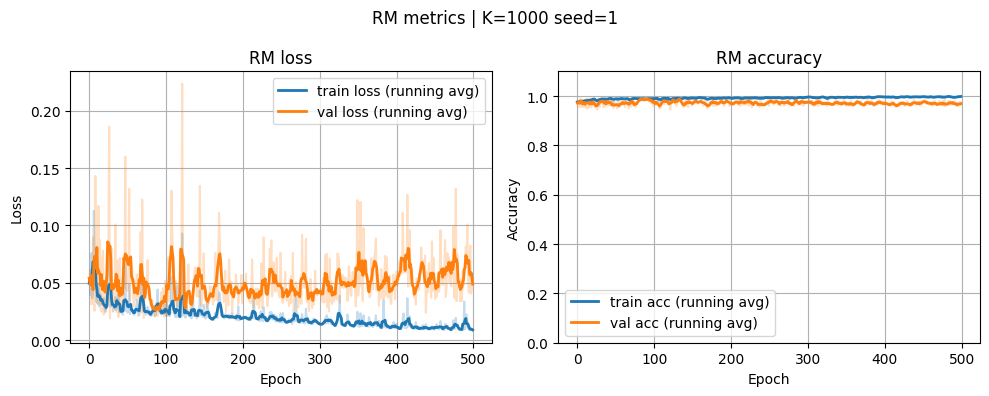

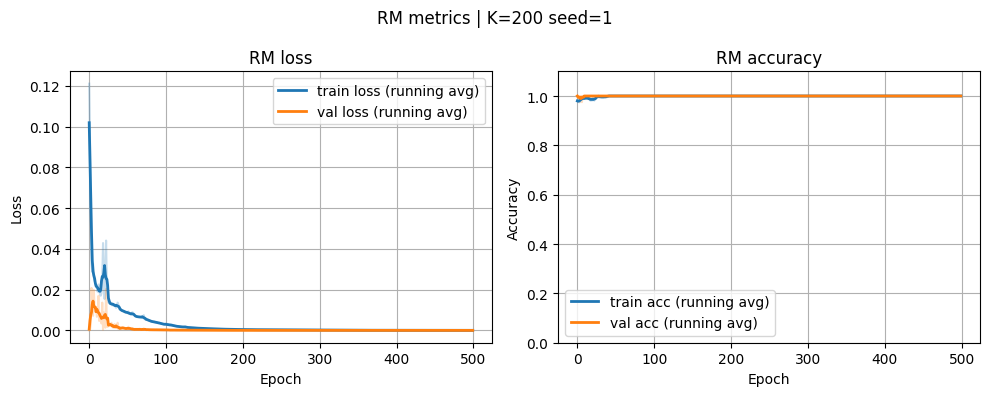

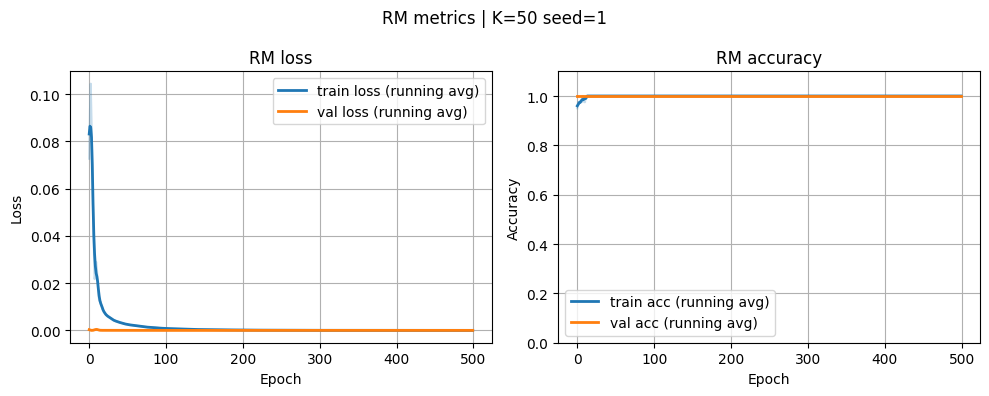

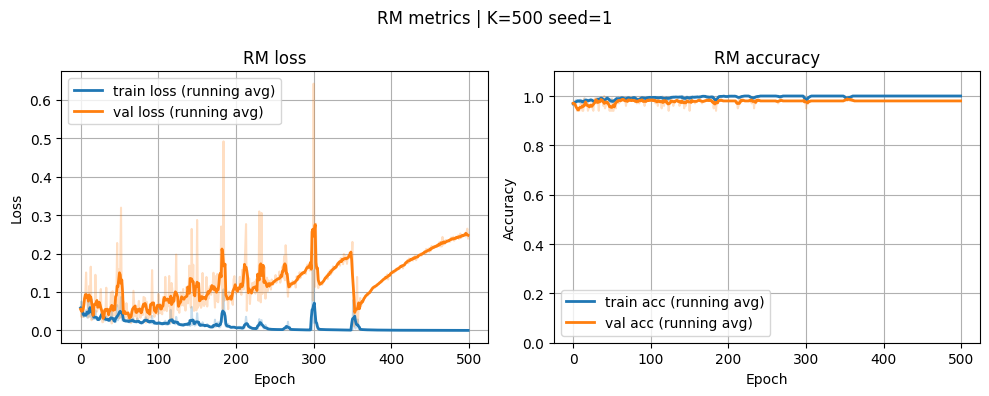

In [35]:
import matplotlib.pyplot as plt


def running_average(values, window=5):
    if len(values) < 2 or window <= 1:
        return list(values)
    arr = np.asarray(values, dtype=float)
    window = min(window, len(arr))
    left_pad = window // 2
    right_pad = window - 1 - left_pad
    padded = np.pad(arr, (left_pad, right_pad), mode="edge")
    weights = np.ones(window, dtype=float) / window
    return np.convolve(padded, weights, mode="valid")


# === Reward model plots ===
for name, history in rm_histories.items():
    meta = rm_meta.get(name, {})
    k = meta.get("K", "?")
    seed = meta.get("seed", "?")
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    train_loss = history["train_loss"]
    val_loss = history["val_loss"]
    train_loss_smooth = running_average(train_loss)
    val_loss_smooth = running_average(val_loss)
    axes[0].plot(train_loss, color="C0", alpha=0.25)
    axes[0].plot(val_loss, color="C1", alpha=0.25)
    axes[0].plot(train_loss_smooth, label="train loss (running avg)", color="C0", linewidth=2.0)
    axes[0].plot(val_loss_smooth, label="val loss (running avg)", color="C1", linewidth=2.0)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("RM loss")
    axes[0].grid(True)
    axes[0].legend()

    train_acc = history["train_acc"]
    val_acc = history["val_acc"]
    train_acc_smooth = running_average(train_acc)
    val_acc_smooth = running_average(val_acc)
    axes[1].plot(train_acc, color="C0", alpha=0.25)
    axes[1].plot(val_acc, color="C1", alpha=0.25)
    axes[1].plot(train_acc_smooth, label="train acc (running avg)", color="C0", linewidth=2.0)
    axes[1].plot(val_acc_smooth, label="val acc (running avg)", color="C1", linewidth=2.0)
    axes[1].set_ylim(0.0, 1.1)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("RM accuracy")
    axes[1].grid(True)
    axes[1].legend()
    fig.suptitle(f"RM metrics | K={k} seed={seed}")
    fig.tight_layout()
    plt.show()

We can now tune the number of epochs depending on the dataset size.

In [55]:
# === Reward model training ===
rm_models: Dict[str, RewardModel] = {}
rm_histories: Dict[str, Dict[str, List[float]]] = {}
rm_meta: Dict[str, Dict[str, int]] = {}

size_to_epochs = {
    50: 40,
    200: 50,
    500: 60,
    1000: 90,
}

if not dataset_list:
    print("No preference datasets found for", ENV_KEY)
else:
    for dataset in dataset_list:
        reward_model, rm_history = train_reward_model(
            dataset.s_pref_list,
            dataset.a_pref_list,
            dataset.s_rej_list,
            dataset.a_rej_list,
            epochs=size_to_epochs[dataset.k]
        )
        key = dataset.path.name
        rm_models[key] = reward_model
        rm_histories[key] = rm_history
        rm_meta[key] = {"K": dataset.k, "seed": dataset.seed}

RM epoch 1/90 | train loss 0.033 acc 0.980 | val loss 0.036 acc 0.990
RM epoch 2/90 | train loss 0.172 acc 0.959 | val loss 0.281 acc 0.955
RM epoch 3/90 | train loss 0.037 acc 0.980 | val loss 0.054 acc 0.960
RM epoch 4/90 | train loss 0.042 acc 0.980 | val loss 0.025 acc 0.985
RM epoch 5/90 | train loss 0.044 acc 0.980 | val loss 0.025 acc 0.985
RM epoch 6/90 | train loss 0.035 acc 0.978 | val loss 0.049 acc 0.970
RM epoch 7/90 | train loss 0.089 acc 0.980 | val loss 0.030 acc 0.985
RM epoch 8/90 | train loss 0.065 acc 0.980 | val loss 0.027 acc 0.985
RM epoch 9/90 | train loss 0.043 acc 0.978 | val loss 0.087 acc 0.945
RM epoch 10/90 | train loss 0.038 acc 0.980 | val loss 0.080 acc 0.955
RM epoch 11/90 | train loss 0.044 acc 0.980 | val loss 0.029 acc 0.985
RM epoch 12/90 | train loss 0.043 acc 0.980 | val loss 0.024 acc 0.985
RM epoch 13/90 | train loss 0.046 acc 0.980 | val loss 0.101 acc 0.955
RM epoch 14/90 | train loss 0.029 acc 0.986 | val loss 0.041 acc 0.970
RM epoch 15/90 

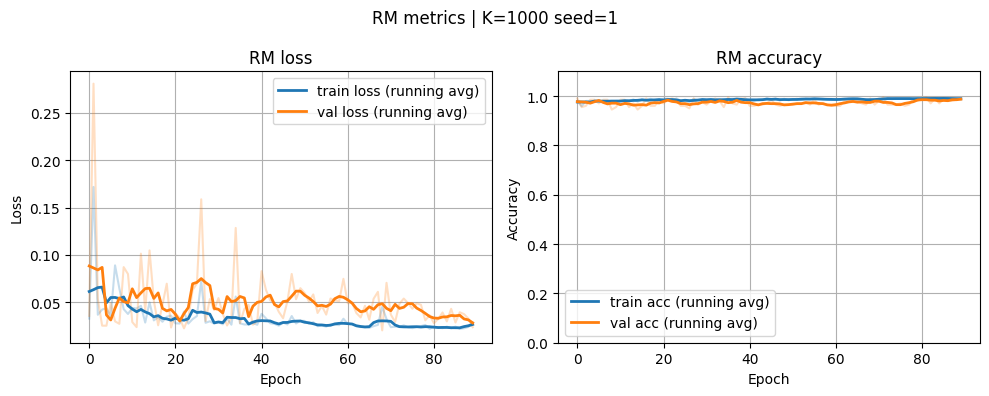

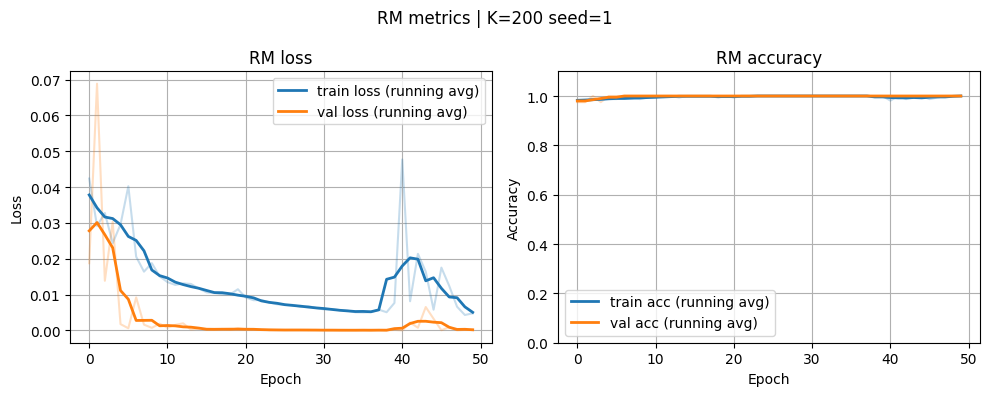

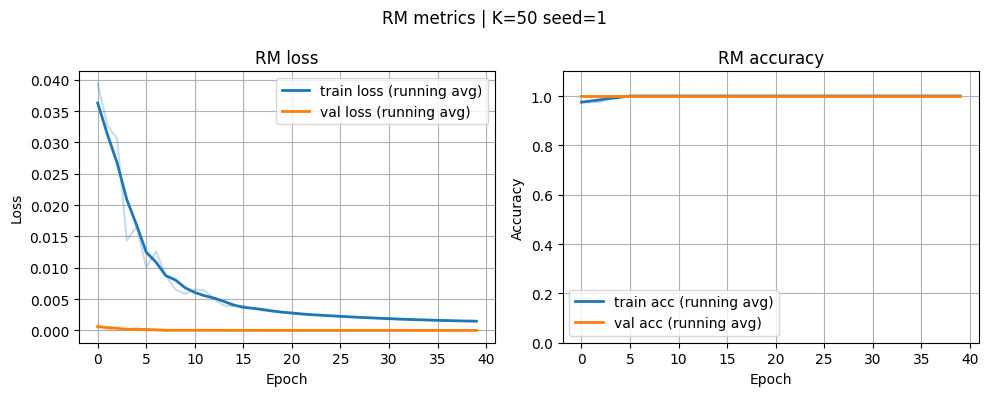

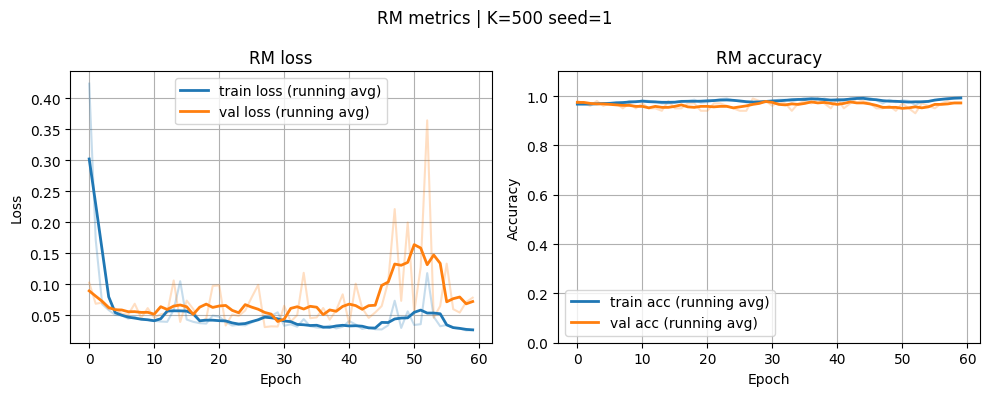

In [56]:
import matplotlib.pyplot as plt


def running_average(values, window=5):
    if len(values) < 2 or window <= 1:
        return list(values)
    arr = np.asarray(values, dtype=float)
    window = min(window, len(arr))
    left_pad = window // 2
    right_pad = window - 1 - left_pad
    padded = np.pad(arr, (left_pad, right_pad), mode="edge")
    weights = np.ones(window, dtype=float) / window
    return np.convolve(padded, weights, mode="valid")


# === Reward model plots ===
for name, history in rm_histories.items():
    meta = rm_meta.get(name, {})
    k = meta.get("K", "?")
    seed = meta.get("seed", "?")
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    train_loss = history["train_loss"]
    val_loss = history["val_loss"]
    train_loss_smooth = running_average(train_loss)
    val_loss_smooth = running_average(val_loss)
    axes[0].plot(train_loss, color="C0", alpha=0.25)
    axes[0].plot(val_loss, color="C1", alpha=0.25)
    axes[0].plot(train_loss_smooth, label="train loss (running avg)", color="C0", linewidth=2.0)
    axes[0].plot(val_loss_smooth, label="val loss (running avg)", color="C1", linewidth=2.0)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("RM loss")
    axes[0].grid(True)
    axes[0].legend()

    train_acc = history["train_acc"]
    val_acc = history["val_acc"]
    train_acc_smooth = running_average(train_acc)
    val_acc_smooth = running_average(val_acc)
    axes[1].plot(train_acc, color="C0", alpha=0.25)
    axes[1].plot(val_acc, color="C1", alpha=0.25)
    axes[1].plot(train_acc_smooth, label="train acc (running avg)", color="C0", linewidth=2.0)
    axes[1].plot(val_acc_smooth, label="val acc (running avg)", color="C1", linewidth=2.0)
    axes[1].set_ylim(0.0, 1.1)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("RM accuracy")
    axes[1].grid(True)
    axes[1].legend()
    fig.suptitle(f"RM metrics | K={k} seed={seed}")
    fig.tight_layout()
    plt.show()

In [57]:
# === Save reward models to disk ===
save_dir = OUTPUT_DIR / "reward_models"
save_dir.mkdir(parents=True, exist_ok=True)
meta_path = save_dir / "rm_meta.pkl"
import pickle
count = 0
for name, model in rm_models.items():
    path = save_dir / f"{name}.pt"
    torch.save(model.state_dict(), path)
    count += 1
with open(meta_path, "wb") as f:
    pickle.dump(rm_meta, f)
print(f"Saved {count} reward models to {save_dir}")

Saved 4 reward models to outputs\part3\reward_models


In [58]:
# === Load reward models from disk ===
save_dir = OUTPUT_DIR / "reward_models"
meta_path = save_dir / "rm_meta.pkl"
if not save_dir.exists():
    print(f"No save directory found at {save_dir}")
else:
    import pickle
    loaded = {}
    for path in sorted(save_dir.glob("*.pt")):
        name = path.stem
        model = RewardModel(ENV_OBS_DIM, ENV_ACTION_DIM, ENV_CONTINUOUS).to(DEVICE)
        state = torch.load(path, map_location=DEVICE)
        model.load_state_dict(state)
        model.eval()
        loaded[name] = model
    if meta_path.exists():
        with open(meta_path, "rb") as f:
            rm_meta = pickle.load(f)
    rm_models = loaded
    print(f"Loaded {len(rm_models)} reward models from {save_dir}")

Loaded 4 reward models from outputs\part3\reward_models


## Run PPO-RLHF / DPO experiments

In [ ]:
results = []
dpo_histories: Dict[int, Dict[str, List[float]]] = {}
ppo_histories: Dict[int, Dict[str, List[float]]] = {}

if not dataset_list:
    print("No datasets available for", ENV_KEY)
else:
    dataset_seeds = {dataset.seed for dataset in dataset_list}
    # Make sure both PPO training and evaluation samples seeds differently from datasets
    ppo_training_seeds = [max(dataset_seeds) + 1 + i for i in range(len(dataset_seeds))]
    eval_seed = max(ppo_training_seeds) + 1
    for i, dataset in enumerate(dataset_list):
        if not dataset.s_pref_list:
            continue
        pref_seed = dataset.seed
        ppo_training_seed = ppo_training_seeds[i]
        assert eval_seed != pref_seed \
            and ppo_training_seed != pref_seed \
            and eval_seed != ppo_training_seed, \
            "Eval and PPO training seeds must differ from each other and from preference dataset seed"
        dpo_policy, dpo_history = train_dpo(
            dataset.s_pref_list,
            dataset.a_pref_list,
            dataset.s_rej_list,
            dataset.a_rej_list,
            eval_seed=eval_seed,
        )
        dpo_mean, dpo_std = eval_policy_true_reward(
            dpo_policy,
            ENV_ID,
            EVAL_EPISODES,
            eval_seed=eval_seed,
        )
        reward_model = rm_models.get(dataset.path.name)
        if reward_model is None:
            raise ValueError(f"Missing reward model for {dataset.path.name}")
        ppo_model, ppo_history = train_ppo_with_reward_model(
            ENV_ID,
            reward_model,
            seed=ppo_training_seed,
            eval_seed=eval_seed,
        )
        ppo_mean, ppo_std = eval_policy_true_reward(
            ppo_model,
            ENV_ID,
            EVAL_EPISODES,
            eval_seed=eval_seed,
        )
        dpo_histories[dataset.k] = dpo_history
        ppo_histories[dataset.k] = ppo_history
        results.append({
            "env": dataset.env_key,
            "dataset": dataset.path.name,
            "K": dataset.k,
            "seed": pref_seed,
            "dpo_return": dpo_mean,
            "dpo_std": dpo_std,
            "ppo_return": ppo_mean,
            "ppo_std": ppo_std,
        })
    if results:
        import pandas as pd
        df = pd.DataFrame(results)
        out_path = OUTPUT_DIR / f"results_{ENV_KEY}.csv"
        df.to_csv(out_path, index=False)
        print("saved:", out_path)

## Plot performance vs K

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


if "df" not in globals():
    result_path = OUTPUT_DIR / f"results_{ENV_KEY}.csv"
    if result_path.exists():
        df = pd.read_csv(result_path)


if "df" in globals() and not df.empty:
    plt.figure(figsize=(8, 4))
    for algo, mean_col, std_col in [
        ("DPO", "dpo_return", "dpo_std"),
        ("PPO-RLHF", "ppo_return", "ppo_std"),
    ]:
        sub = df.groupby("K").agg({mean_col: "mean", std_col: "mean"}).reset_index()
        plt.plot(sub["K"], sub[mean_col], marker="o", label=algo)
        lower = sub[mean_col] - sub[std_col]
        upper = sub[mean_col] + sub[std_col]
        plt.fill_between(sub["K"], lower, upper, alpha=0.2)
    plt.xlabel("K (preference dataset size)")
    plt.ylabel("Average return")
    plt.title(f"{ENV_KEY} performance vs K")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No results available to plot.")

In [ ]:
import matplotlib.pyplot as plt

if dpo_histories or ppo_histories:
    ordered_ks = sorted(set(dpo_histories) | set(ppo_histories))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, title, histories in [
        (axes[0], "DPO", dpo_histories),
        (axes[1], "PPO-RLHF", ppo_histories),
    ]:
        for k in ordered_ks:
            history = histories.get(k)
            if not history:
                continue
            steps = history["steps"]
            mean_reward = history["mean_reward"]
            std_reward = history["std_reward"]
            ax.plot(steps, mean_reward, marker="o", label=f"K={k}")
            ax.fill_between(
                steps,
                [m - s for m, s in zip(mean_reward, std_reward)],
                [m + s for m, s in zip(mean_reward, std_reward)],
                alpha=0.2,
            )
        ax.set_title(title)
        ax.set_xlabel("Training steps")
        ax.grid(True)
    axes[0].set_ylabel("True reward")
    axes[1].legend(title="K")
    fig.suptitle(f"{ENV_KEY} checkpoint reward curves")
    fig.tight_layout()
    plt.show()
else:
    print("No checkpoint histories available yet. Run the training cell first.")